#**Projet Intro au TAL (M1 Informatique)**
**Compétition DEFT2013 Tâche 2 - Classification de recettes**

Projet TAL : Classification de Recettes de Cuisine (DEFT 2013)
L'objectif de ce projet est d'analyser un corpus de recettes de cuisine et de prédire automatiquement leur catégorie (Entrée, Plat principal ou Dessert).

**Importation des bibliothèques**

In [58]:
import pandas as pd
import numpy as np
import re
from collections import Counter
import spacy
!python -m spacy download fr_core_news_sm
nlp = spacy.load("fr_core_news_sm")
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

stop_words_set = set([
    'à', 'ces', 'le', 'toujours', "quelqu'un", 'plus', 'quoi', 'telle', 'rien',
    'cette', 'tous', 'maintenant', 'avec', 'qu', 'moins', 'pas', 'cet',
    'parfois', 'souvent', 'seule', 'tels', 'hier', 'aux', 'chacun', 'quelques',
    'aujourd', 'neuf', 'quelqu', 'ne', 'ni', 'toute', 'tout', 'ensemble',
    'avant', 'au', 'un', "aujourd'hui", 'la', 'des', 'si', 'seul', 'telles',
    'peu', 'chaque', 'tant', 'de', 'par', 'pour', 'tellement', 'quelquefois',
    'ce', 'car', 'que', 'lorsque', 'assez', 'en', 'enfin', 'sur', 'où',
    'personne', 'demain', 'donc', 'puis', 'qui', 'dans', 'aussi', 'lors',
    'et', 'jamais', 'depuis', 'beaucoup', 'ensuite', 'chacune', 's', 'autre',
    'alors', 'pendant', 'même', 'plusieurs', 'après', 'trop', 'dont', 'une',
    'mais', 'ou', 'or', "quelqu'une", 'du', 'les', 'autres', 'tel'
])
stop_words_set.update(nlp.Defaults.stop_words)
stop_words = list(stop_words_set)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 76.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


 **Chargement des données**

In [59]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(train.shape)
train.head()

(12473, 7)


,doc_id,titre,type,difficulte,cout,ingredients,recette
0,recette_221358.xml,"Feuilleté de saumon et de poireau, sauce aux c...",Plat principal,Facile,Moyen,- 1 gros pavé de saumon - 100 g de crevettes d...,Couper finement le blanc et un peu de vert des...
1,recette_48656.xml,Cake poulet/moutarde/amandes,Entrée,Très facile,Bon marché,- 3 œufs - 150 g de farine - 1 sachet de levur...,"Couper finement l'échalote, la faire revenir à..."
2,recette_30049.xml,Bûche à la truite fumée (7ème rencontre),Entrée,Moyennement difficile,Assez Cher,- 800 g de filet de truite saumonnée fumée en ...,Faites blanchir les épinards à l'eau bouillant...
3,recette_71424.xml,Gâteau au yaourt au coco sans huile de laetitia,Dessert,Très facile,Bon marché,- 1 pot de yaourt - 1 pot de lait de coco - 3 ...,Mélanger dans l'ordre tous les ingrédients en ...
4,recette_217204.xml,Crêpes au canard laqué,Entrée,Moyennement difficile,Moyen,- 90 g de farine - 45 g de maïzena - 2 œufs - ...,"Fouetter les œufs avec l'eau, le lait et le su..."


**Fonction de calculs des métriques**

**Note**: Pour notre tache (une classification multiclasse où chaque recette n'appartient qu'à une seule catégorie), l'Accuracy et le score Micro-F1 sont mathématiquement équivalents. En effet, quand la classe est unique, chaque erreur de prédiction génère exactement un faux positif pour la classe prédite à tort, et un faux négatif pour la classe réelle. La somme totale des faux positifs sur l'ensemble du corpus est donc strictement égale à la somme totale des faux négatifs. Par conséquent, la micro-précision, le micro-rappel et l'accuracy ont exactement la même valeur, tout comme le Micro-F1 qui en est la moyenne harmonique. Nous avons donc retiré l'accuracy des métriques pour éviter la redondance.

In [60]:
def metrics(predictions):
  classes = train['type'].dropna().unique()

  micro_f1 = f1_score(test['type'], predictions, average='micro')
  print("Micro-F1:",micro_f1,"\n")

  macro_f1 = f1_score(test['type'], predictions, average='macro')
  print("Macro-F1:",macro_f1,"\n")

  print("Classification Report:","\n")
  print(classification_report(test['type'], predictions))

  print("Confusion Matrix:")
  print(confusion_matrix(test['type'], predictions, labels=classes))

# 1.   Exploration des données


**Nombre de documents**

Nombre de documents total : Train = 12473 



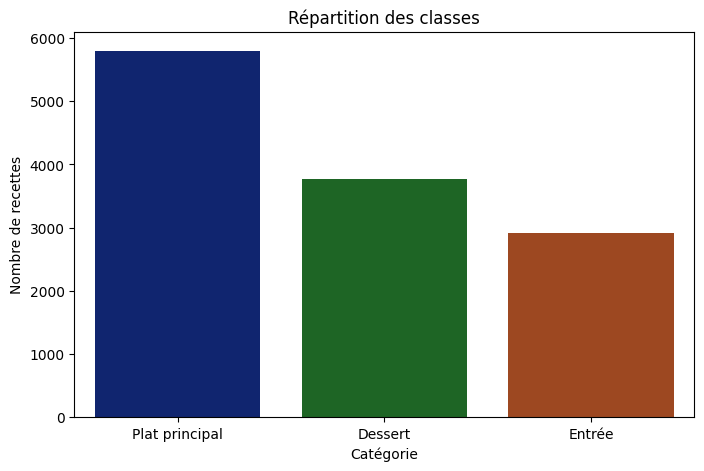

In [61]:
print("Nombre de documents total : Train =",len(train),"\n")

plt.figure(figsize=(8, 5))
sns.countplot(data=train, x='type', hue='type',legend=False, palette='dark', order=train['type'].value_counts().index)
plt.title('Répartition des classes')
plt.ylabel('Nombre de recettes')
plt.xlabel('Catégorie')
plt.show()

**Observation**: Il y a un fort déséquilibre dans la répartition : "Plat principal" représente environ 46.5% des données, tandis que les entrées n'en représentent que 23.3%.

**Analyse de la longueur des documents**

Longueur médiane des recettes par classe :
type
Dessert           108.0
Entrée            101.0
Plat principal    114.0
Name: recette_len, dtype: float64

Longueur médiane des ingrédients par classe :
type
Dessert           41.0
Entrée            41.0
Plat principal    46.0
Name: ingr_len, dtype: float64

Longueur médiane des titres par classe :
type
Dessert           5.0
Entrée            5.0
Plat principal    5.0
Name: titre_len, dtype: float64



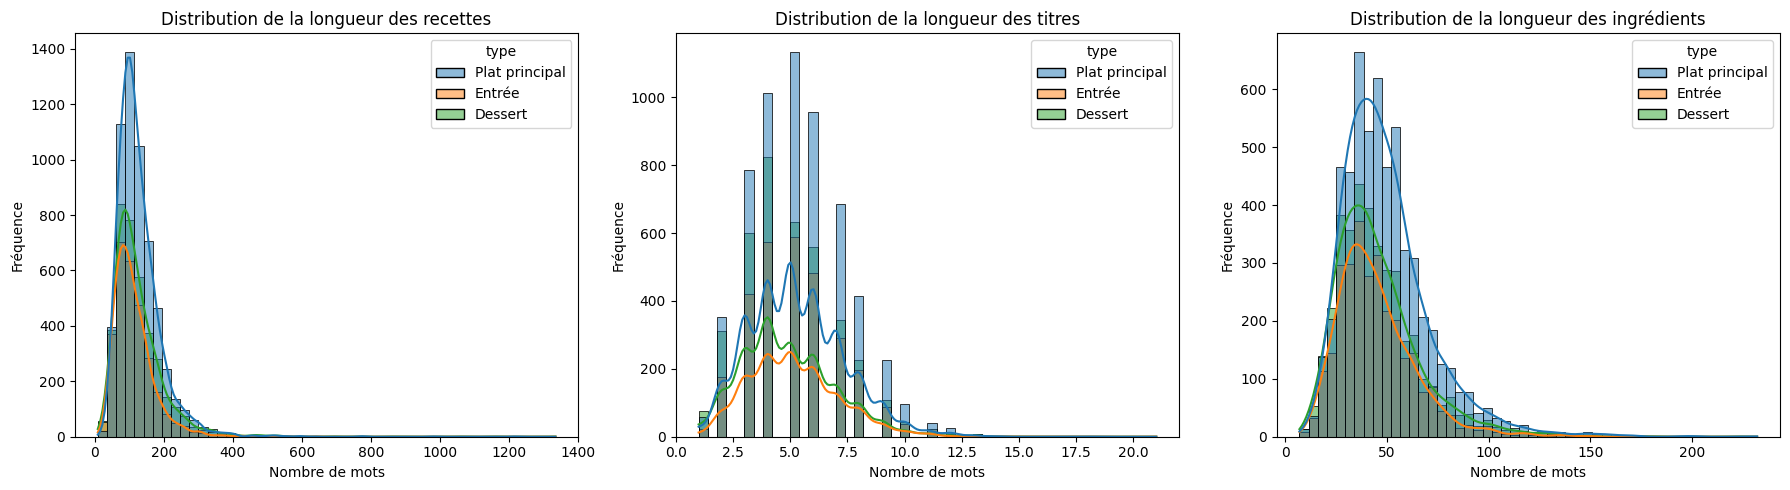

In [62]:
train['recette_len'] = train['recette'].astype(str).str.split().str.len()
train['ingr_len'] = train['ingredients'].astype(str).str.split().str.len()
train['titre_len'] = train['titre'].astype(str).str.split().str.len()

print("Longueur médiane des recettes par classe :")
print(train.groupby('type')['recette_len'].median())
print("\nLongueur médiane des ingrédients par classe :")
print(train.groupby('type')['ingr_len'].median())
print("\nLongueur médiane des titres par classe :")
print(train.groupby('type')['titre_len'].median())
print()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Recette
sns.histplot(data=train, x='recette_len', hue='type', kde=True, ax=axes[0], bins=50)
axes[0].set_title('Distribution de la longueur des recettes')
axes[0].set_xlabel('Nombre de mots')
axes[0].set_ylabel('Fréquence')

# Titres
sns.histplot(data=train, x='titre_len', hue='type', kde=True, ax=axes[1], bins=50)
axes[1].set_title('Distribution de la longueur des titres')
axes[1].set_xlabel('Nombre de mots')
axes[1].set_ylabel('Fréquence')

# Ingrédients
sns.histplot(data=train, x='ingr_len', hue='type', kde=True, ax=axes[2], bins=50)
axes[2].set_title('Distribution de la longueur des ingrédients')
axes[2].set_xlabel('Nombre de mots')
axes[2].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

**Observation**: Bien que les moyennes de longueur de texte soient assez proches entre les catégories, l'analyse de la distribution révèle des différences plus marqués. En observant la répartition des documents, on constate que la majorité des entrées comportent moins de mots que les desserts, eux-mêmes plus courts que les plats principaux. L'écart de longueur est particulièrement important entre les plats principaux et les entrées.

**Analyse de la distribution du coût et de la difficulté**

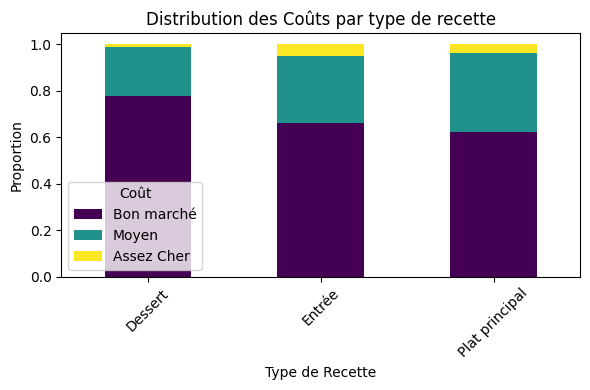

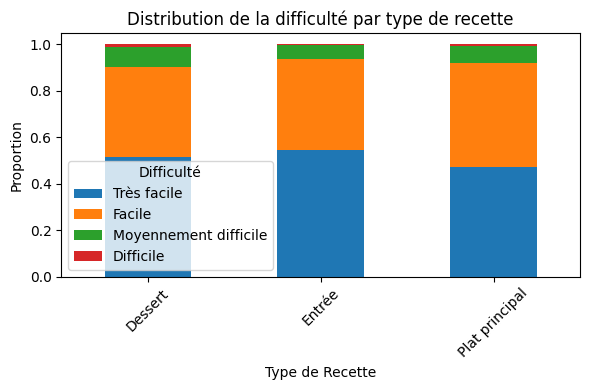

In [63]:
cost_counts = train.groupby('type')['cout'].value_counts()
cost_proportions = train.groupby('type')['cout'].value_counts(normalize=True)

cost_proportions_df = cost_proportions.unstack(level='cout')
cost_proportions_df = cost_proportions_df[['Bon marché', 'Moyen', 'Assez Cher']]

cost_proportions_df.plot(kind='bar', stacked=True, figsize=(6, 4), colormap='viridis')
plt.title('Distribution des Coûts par type de recette')
plt.xlabel('Type de Recette')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.legend(title='Coût')
plt.tight_layout()
plt.show()
print()
cost_proportions = train.groupby('type')['difficulte'].value_counts(normalize=True)

cost_proportions_df = cost_proportions.unstack(level='difficulte')
cost_proportions_df = cost_proportions_df[['Très facile','Facile','Moyennement difficile','Difficile']]

cost_proportions_df.plot(kind='bar', stacked=True, figsize=(6, 4))
plt.title('Distribution de la difficulté par type de recette')
plt.xlabel('Type de Recette')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.legend(title='Difficulté')
plt.tight_layout()
plt.show()



**Observations**: On observe que les distributions du coût et de la difficulté sont quasi identiques pour toutes les catégories. Ces variables ne sont donc pas vraiment discriminantes, ce qui indique qu'elles seront probablement inutiles pour aider nos modèles et qu'elles n'apporteraient que du bruit.

**Quelques exemples**

In [64]:
np.random.seed(42)
i=np.random.randint(50)
print("Exemples d'entrées","\n")
print(train.loc[train['type']=='Entrée'].iloc[i],"\n")
print(train.loc[train['type']=='Entrée'].iloc[i*2],"\n")
print("******************","\n")
print("Exemples de plats","\n")
print(train.loc[train['type']=='Plat principal'].iloc[i],"\n")
print(train.loc[train['type']=='Plat principal'].iloc[i*2],"\n")
print("******************","\n")
print("Exemples de desserts","\n")
print(train.loc[train['type']=='Dessert'].iloc[i],"\n")
print(train.loc[train['type']=='Dessert'].iloc[i*2],"\n")

Exemples d'entrées 

doc_id                                         recette_72303.xml
titre          Salade d'été au saumon fumé, feta, pommes et c...
type                                                      Entrée
difficulte                                           Très facile
cout                                                  Bon marché
ingredients    - 1 concombre - 2 carottes - 2 pommes Golden o...
recette        Eplucher le concombre et le détailler en laniè...
recette_len                                                  157
ingr_len                                                      64
titre_len                                                      9
Name: 182, dtype: object 

doc_id                                         recette_23531.xml
titre          Foie gras au micro-onde et son croustillant d'été
type                                                      Entrée
difficulte                                           Très facile
cout                                      

**Observation**: En analysant quelques exemples de recettes pour découvrir et comprendre les données, on remarque une certaine ambiguïté sémantique. En effet, certains ingrédients peuvent facilement induire en erreur un modèle : par exemple, la présence d’abricots, souvent associés aux desserts, dans un plat principal, ou encore celle de fromage dans un dessert.

On se rend également compte que les catégories "plat", "dessert" et "entrée" sont plus ambiguës qu’on ne le pensait, ce qui rend la tâche de classification plus difficile. Par exemple, on pourrait largement débattre pour savoir si une tarte au fromage est une entrée ou un dessert; la réponse pourrait être que c’est les deux, alors qu’on doit en choisir une seule.

Pour les entrées, le seul terme qui permettrait de lever cette ambiguïté serait "salade", mais au niveau des ingrédients seuls, cela n’aide pas vraiment, surtout pour différencier une entrée d’un plat, d’autant que certains ingrédients comme les pommes peuvent évoquer un dessert.

Ainsi, les mots réellement discriminants seront surtout des termes comme "cake", "tarte", "salade", etc., plutôt que les ingrédients seuls. Le titre de la recette contient également des informations discriminantes, mais d’autres, comme "truffe géante de la mère Anne" ou "Tarte au fromage de Marisé", apportent peu d’information ou introduisent du bruit et des mots très rare.


**Analyse des top words**

Top words par type (recette):


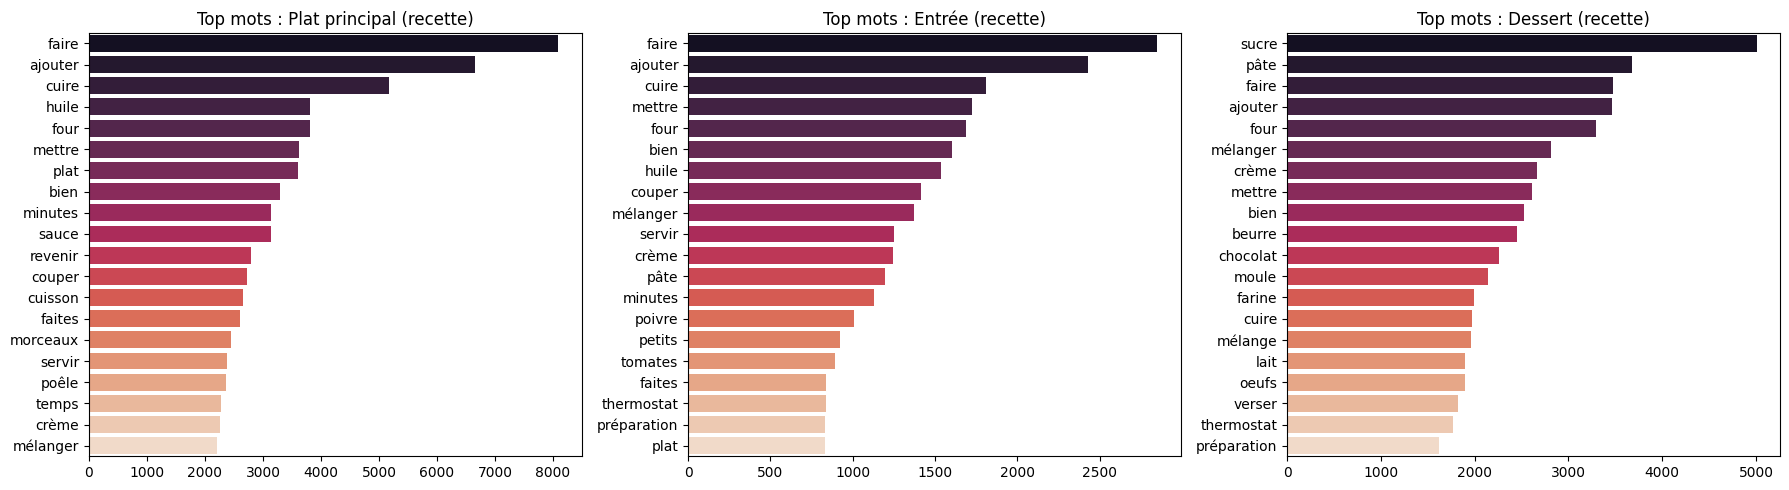

Top words par type (ingredients):


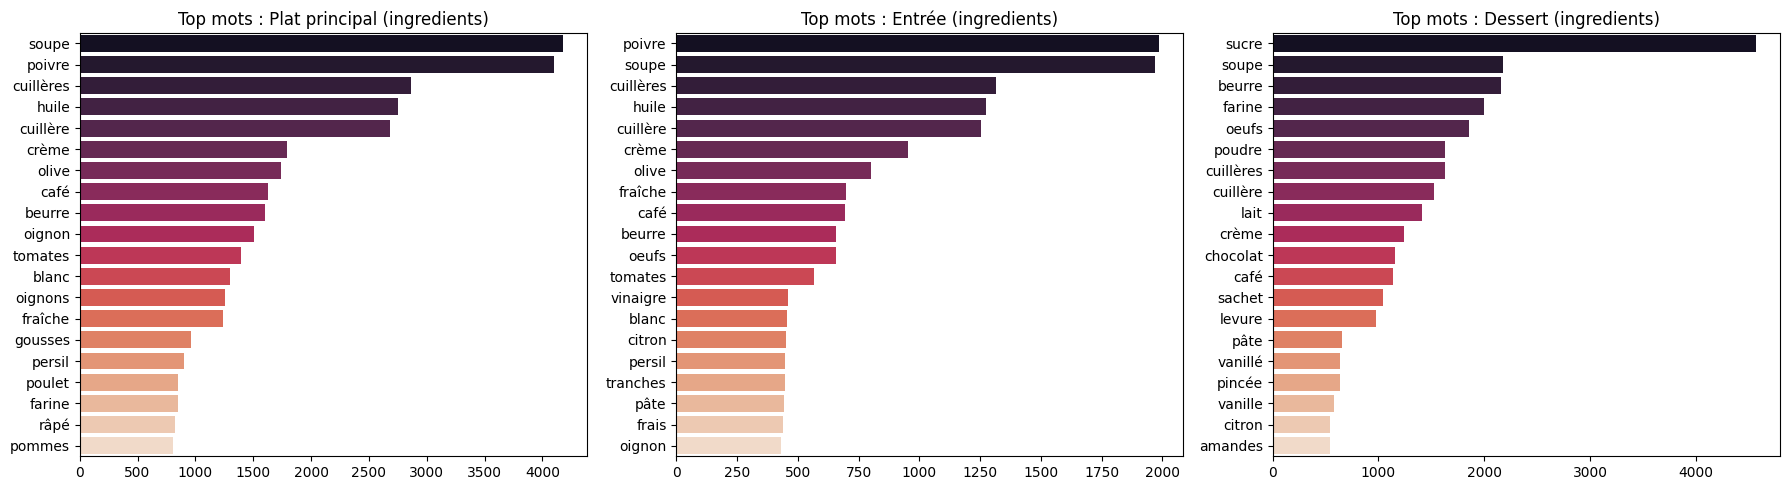

Top words par type (titre):


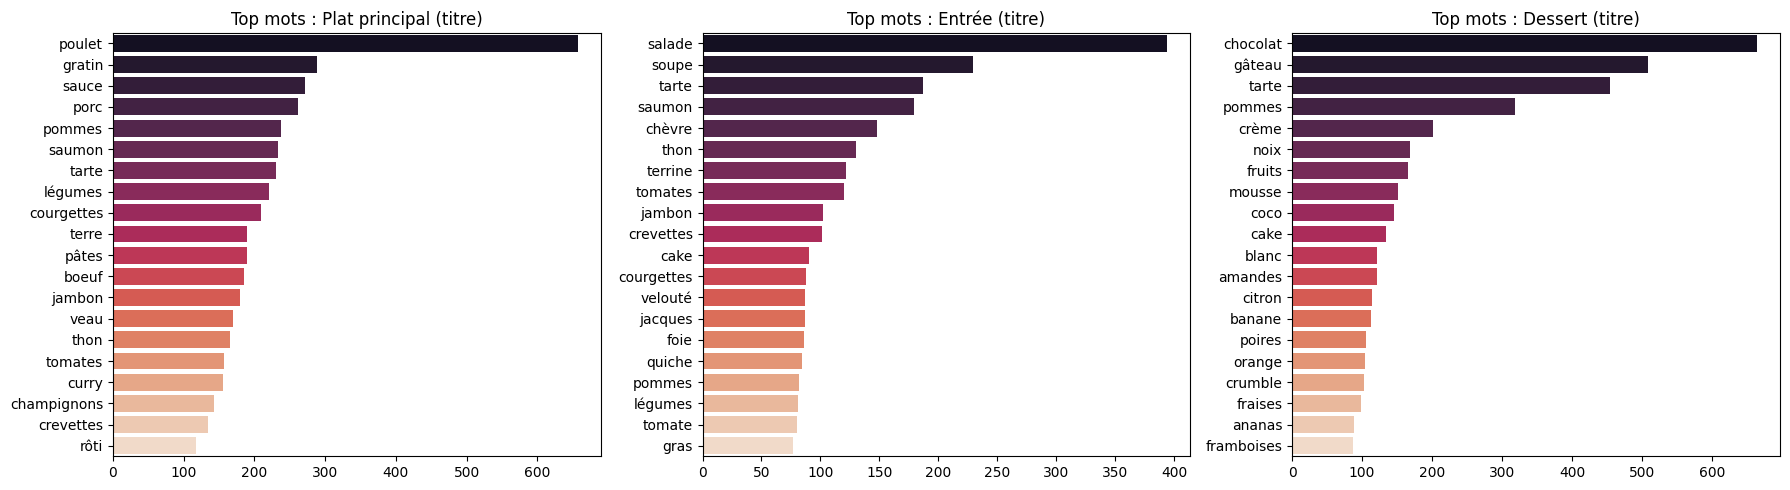

In [65]:
def get_top_words(df, category, classe, n=20):
    text = " ".join(df[df['type'] == category][classe].astype(str)).lower()
    words = re.findall(r'\w+', text)
    words = [w for w in words if w not in stop_words and len(w) > 3]
    return Counter(words).most_common(n)

for classe in ['recette', 'ingredients', 'titre']:
  top_word = {}
  fig, axes = plt.subplots(1, 3, figsize=(18, 5))
  print(f"Top words par type ({classe}):")
  for i, cat in enumerate(train['type'].unique()):
      top_words = get_top_words(train, cat,classe)
      top_word[cat]=top_words
      words, counts = zip(*top_words)
      sns.barplot(x=list(counts), y=list(words), hue=list(words), ax=axes[i], palette='rocket')
      axes[i].set_title(f"Top mots : {cat} ({classe})")

  plt.tight_layout()
  plt.show()

**Observation**: Les graphiques montrent que la catégorie des desserts se démarque très nettement grâce à beaucoup de termes fortement discriminants (sucre, chocolat, gâteau, farine, beurre), que ce soit dans les titres ou les ingrédients. À l'inverse, il y a une forte ambiguïté entre les entrées et les plats principaux, qui partagent énormément de vocabulaire salé (soupe, poivre, huile, cuillères). Enfin, on remarque que la colonne "recette" inclus des verbes d'action très génériques (faire, ajouter, cuire, mettre) mais également des ingrédients (huile, crème, pâtes, tomates, chocolat) et que, comme les autres colonnes, elle n'est pas très discriminante quand il s'agit de comparer plats et entrées, mais elle l'est pour les desserts. En conclusion, chaque colonne permet de discriminer les desserts, mais aucune n'est vraiment utile pour départager plats et entrées.

**Analyse des top words uniques**

Top words uniques par type (recette):


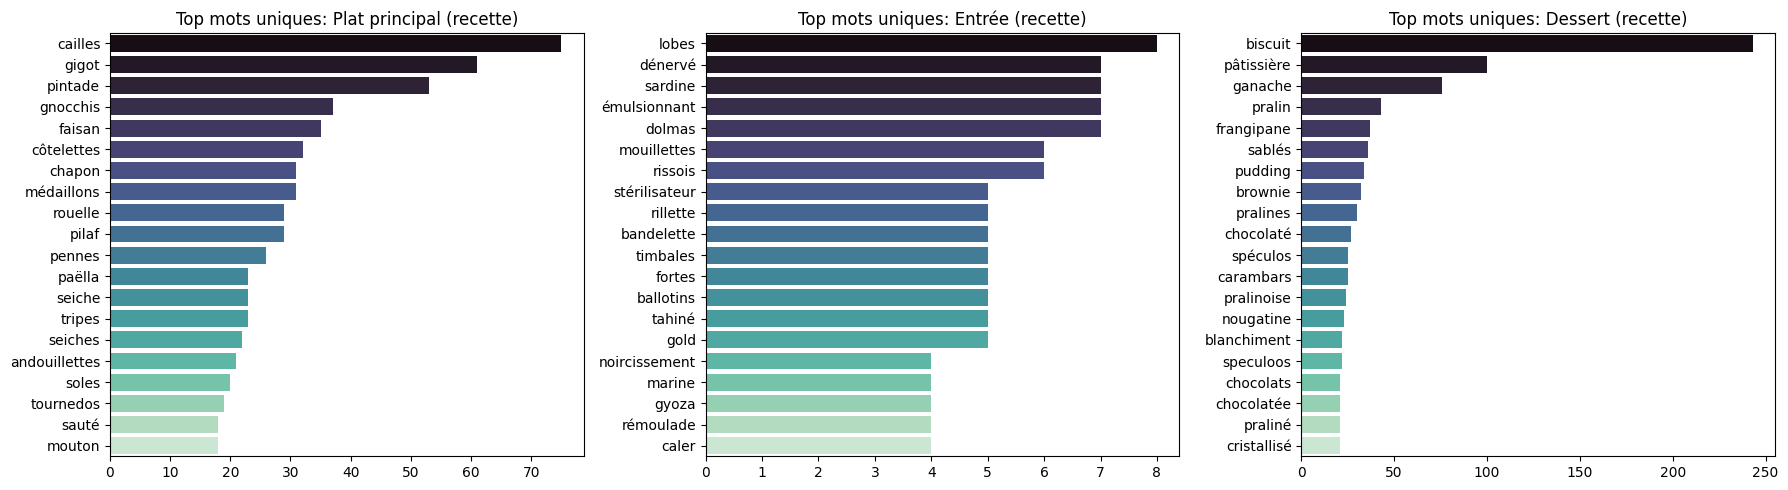

Top words uniques par type (ingredients):


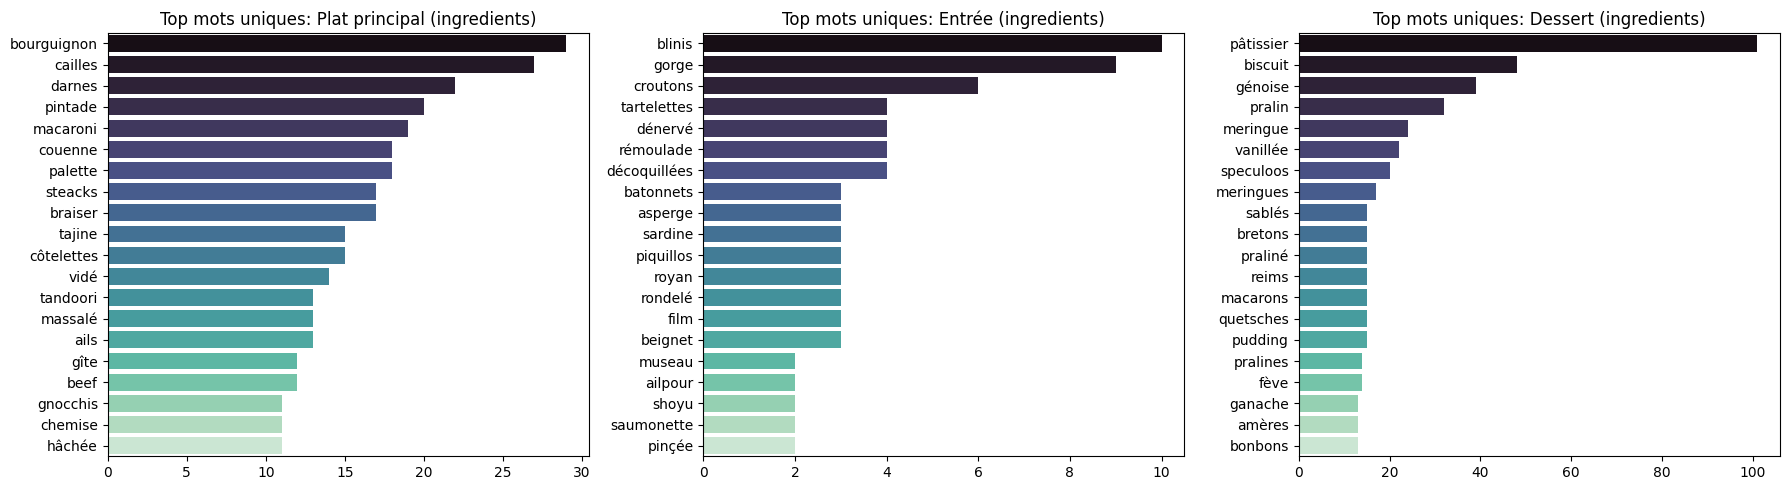

Top words uniques par type (titre):


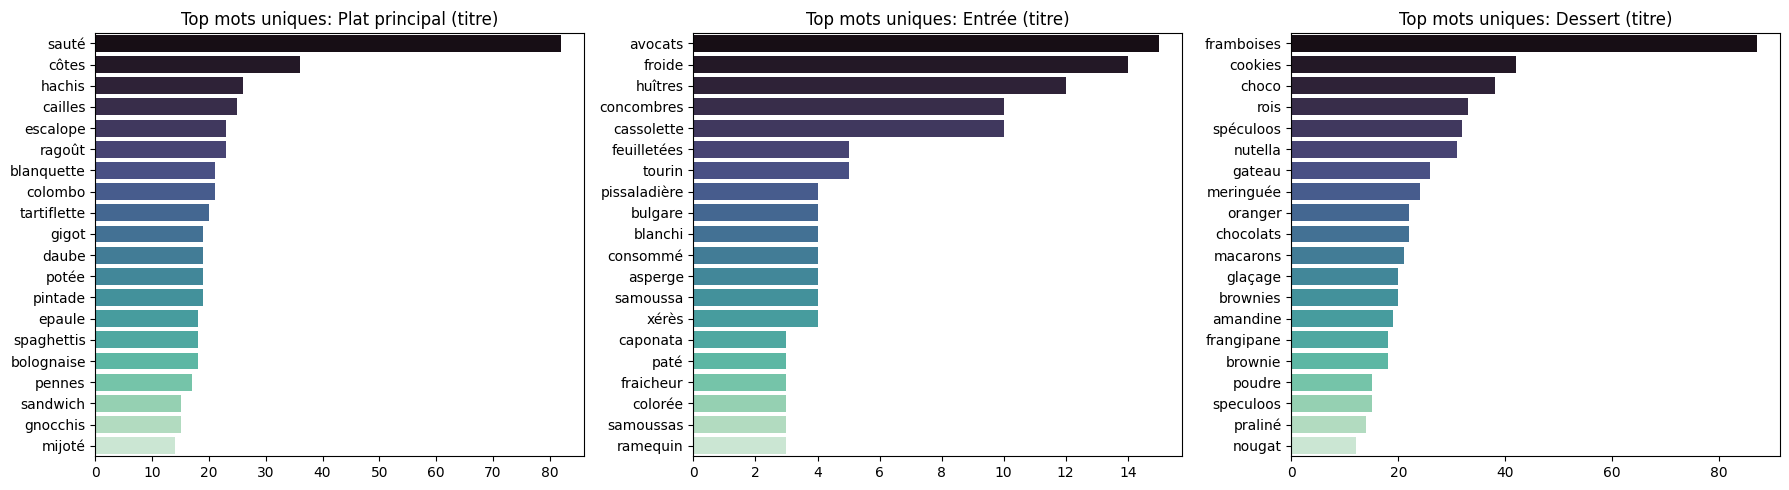

In [66]:
def get_words(df, category, classe):
    text = " ".join(df[df['type'] == category][classe].astype(str)).lower()
    words = re.findall(r'\w+', text)
    words = [w for w in words if w not in stop_words]
    return words

for classe in ['recette', 'ingredients', 'titre']:
    unique_words_by_cat = {}
    all_words_by_cat = {cat: get_words(train, cat, classe) for cat in train['type'].unique()}
    for cat, words in all_words_by_cat.items():
        words_set = set(words)
        other_words = set().union(*(set(w) for c, w in all_words_by_cat.items() if c != cat))
        unique_words = words_set - other_words
        unique_words_by_cat[cat] = unique_words
    top_unique_words_by_cat = {}
    for cat, words in unique_words_by_cat.items():
        counts = Counter([w for w in all_words_by_cat[cat] if w in words])
        top_unique_words_by_cat[cat] = counts.most_common(20)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    print(f"Top words uniques par type ({classe}):")
    for i, cat in enumerate(train['type'].unique()):
        words, counts = zip(*top_unique_words_by_cat[cat]) if top_unique_words_by_cat[cat] else ([], [])
        sns.barplot(x=list(counts), y=list(words), hue=list(words), ax=axes[i], palette='mako', dodge=False)
        axes[i].set_title(f"Top mots uniques: {cat} ({classe})")

    plt.tight_layout()
    plt.show()

**Observation**: L'analyse des mots uniques à chaque catégorie confirme nos observations sur les desserts. Les mots uniques de cette catégorie (biscuit, ganache, framboises...) sont très présents dans le corpus comparés aux autres catégories (jusqu'à 250 occurrences pour biscuit par exemple). Les plats principaux parviennent aussi à se démarquer grâce à des mots uniques moyennement fréquents, majoritairement des ingrédients. En revanche, la véritable difficulté de la tâche reste les entrées : les mots uniques de cette catégorie (avocats, huîtres, blinis...) sont très rares (maximum 15). Cela reprend les conclusions précédentes : il sera très difficile de départager les plats et les entrées.

**Analyse des bi-grammes**

**Note**: Nous avons fait le choix d'analyser les bi-grammes des recettes uniquement, car c'est ce qui va être le plus pertinent vu que les textes des recettes sont plus longs que les ingrédients et le titre.

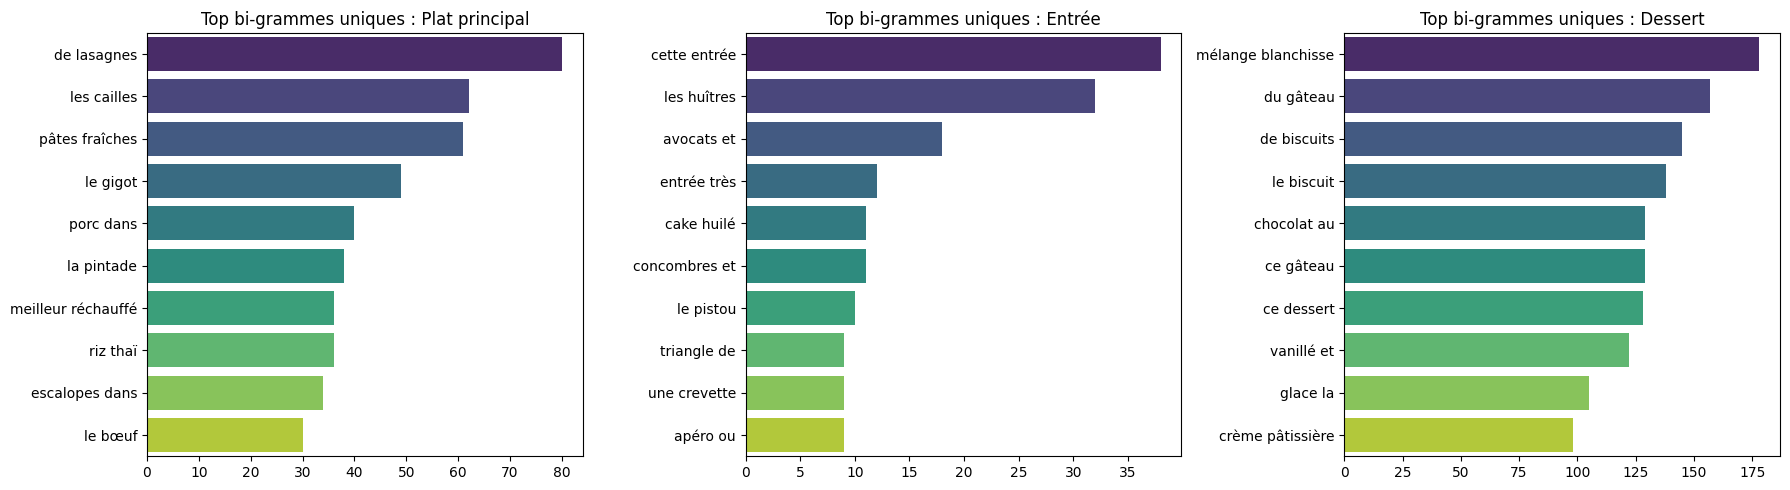

In [67]:
def plot_top_unique_bigrams(df, n=10):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    classes = df['type'].unique()

    bigrams_by_class = {}
    freq_by_class = {}

    for cls in classes:
        corpus = df[df['type'] == cls]['recette'].astype(str)
        vec = CountVectorizer(ngram_range=(2, 2)).fit(corpus)
        bag = vec.transform(corpus)
        sum_words = bag.sum(axis=0)

        freq = {word: sum_words[0, idx] for word, idx in vec.vocabulary_.items()}
        bigrams_by_class[cls] = set(freq.keys())
        freq_by_class[cls] = freq

    unique_bigrams = {}
    for cls in classes:
        others = set().union(*(bigrams_by_class[c] for c in classes if c != cls))
        unique_bigrams[cls] = bigrams_by_class[cls] - others

    for i, cls in enumerate(classes):
        freq = freq_by_class[cls]
        uniques = unique_bigrams[cls]

        words_freq = [(w, freq[w]) for w in uniques]
        words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:n]

        words, counts = zip(*words_freq) if words_freq else ([], [])
        sns.barplot(x=list(counts), y=list(words), hue=list(words), ax=axes[i], palette='viridis', dodge=False)
        axes[i].set_title(f"Top bi-grammes uniques : {cls}")

    plt.tight_layout()
    plt.show()

plot_top_unique_bigrams(train)

**Observation**: Exactement les mêmes observations que les top words uniques.

# Conclusion de l'exploratrion des données d'après les observations

**Les titres seuls sont-ils discriminants ?**

Ils le sont fortement pour les desserts et moyennement pour les plats principaux. En revanche, ils le sont beaucoup moins pour les entrées, qui sont facilement confondables avec les plats principaux et possèdent très peu de mots uniques. Néanmoins, les titres contiennent tout de même certains mots discriminants (comme cake, quiche, salade) que l'on ne trouverait pas forcément dans les instructions ou les ingrédients. En conclusion, les titres sont trop courts en moyenne et manquent de vocabulaire pour suffire à eux seuls à la classification, mais ils restent une information utile.

---

**Les instructions seules suffisent-elles ?**

Oui et non. Bien que les instructions contiennent le plus de mots ainsi que les ingrédients, elles comportent du bruit avec les verbes d'action  ("faire", "ajouter", "cuire"...) partagés par toutes les catégories. Elles permettront d'identifier facilement les desserts grâce à la présence d'ingrédients sucrés, mais seront limitées pour les entrées.

---


**Certaines recettes semblent-elles ambiguës ?**

Oui, il existe une très forte ambiguïté entre les entrées et les plats principaux (mais aussi avec les desserts avec la tarte au fromage par exemple). Ces deux catégories partagent un vocabulaire commun salé tandis que la classe des entrées manque de mots uniques fréquents pour se démarquer. Au-delà des données, la différence entre une entrée et un plat est naturellement floue : c'est souvent la taille des portions qui permet de les différencier, donc certaines recettes peuvent appartenir à plusieurs catégories. Un système multi-étiquettes aurait peut-être été plus proche de la réalité culinaire. Ici, nous ne devons en prédire qu'une seule, donc les performances en seront forcément impactées : il est techniquement impossible d'atteindre 100 % d'accuracy.



# 2.   Mise en place des baselines


**Baseline 1 : Prédiction aléatoire**

In [68]:
np.random.seed(42)
predictions = np.random.choice(train['type'].unique(), size=len(test))
metrics(predictions)

Micro-F1: 0.3451008645533141 

Macro-F1: 0.3367993024908092 

Classification Report: 

                precision    recall  f1-score   support

       Dessert       0.32      0.36      0.34       407
        Entrée       0.23      0.31      0.27       337
Plat principal       0.48      0.35      0.41       644

      accuracy                           0.35      1388
     macro avg       0.34      0.34      0.34      1388
  weighted avg       0.37      0.35      0.35      1388

Confusion Matrix:
[[228 211 205]
 [124 106 107]
 [127 135 145]]


**Observations :** Le Micro et le Macro-F1 sont d'environ 0,33. Ce résultat est logique car il correspond à la probabilité de prédire la bonne classe au hasard parmi nos trois catégories (1/3).

**Baseline 2 : Classe majoritaire**

In [69]:
majority = train['type'].value_counts().idxmax()
predictions=np.full(shape=len(test),fill_value=majority)
metrics(predictions)

Micro-F1: 0.46397694524495675 

Macro-F1: 0.21128608923884515 

Classification Report: 

                precision    recall  f1-score   support

       Dessert       0.00      0.00      0.00       407
        Entrée       0.00      0.00      0.00       337
Plat principal       0.46      1.00      0.63       644

      accuracy                           0.46      1388
     macro avg       0.15      0.33      0.21      1388
  weighted avg       0.22      0.46      0.29      1388

Confusion Matrix:
[[644   0   0]
 [337   0   0]
 [407   0   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Observations :** Le pourcentage de la classe majoritaire est le seul critère de la baseline 2. Notre modèle devra dépasser les 46.5% d'accuracy.
Le warning signale une division par zéro, car le modèle n'a fait absolument aucune prédiction pour les "Entrées" et les "Desserts".

**Prétraitement du texte et mise en place du tokenizer**

Pour entraîner nos modèles, nous avons fait le choix de concaténer les champs "titre", "ingrédients" et "recette" pour chaque document. Comme démontré lors de l'exploration des données, chaque champ possède ses propres forces : les ingrédients sont discriminants grâce aux termes sucrés et salés, le titre comporte des termes discriminants que l'on ne retrouve pas dans les ingrédients, et la recette comporte plus de mots, offrant ainsi une richesse lexicale supplémentaire.

En revanche, nous avons exclu les variables "coût" et "difficulté", car ces informations ne sont pas discriminantes et n'apporteraient que du bruit au modèle.

Pour le tokenizer, nous avons décidé de retirer la ponctuation et d'utiliser le lemme des mots pour réduire le bruit (en unifiant les variantes d'un même mot) afin que le modèle puisse mieux généraliser avec un vocabulaire plus compact.

In [70]:
# Concaténation du texte
train['texte'] = train['titre'].fillna('') + " " + train['ingredients'].fillna('') + " " + train['recette'].fillna('')
test['texte'] = test['titre'].fillna('') + " " + test['ingredients'].fillna('') + " " + test['recette'].fillna('')

# Définition du tokenizer
def spacy_tokenizer(text):
    tokens = nlp(text)
    return [token.lemma_ for token in tokens if not token.is_punct]

X_train=train['texte']
y_train=train['type']
X_test=test['texte']
y_test=test['type']

# **Méthode A : Sac de mots + Naïve Bayes**

Dans cette approche, nous utilisons :
1. **TF-IDF**
2. **Modèle Naive Bayes**

TF-IDF

Nous avons configuré le vectoriseur TF-IDF avec trois paramètres pour optimiser l'apprentissage. Le choix de lowercase=True permet d'unifier le vocabulaire et d'éviter que le modèle considère "Chocolat" et "chocolat" comme deux variables distinctes. Nous avons fixé max_df=0.95 pour exclure les termes présents dans plus de 95 % des recettes (comme "eau" ou "huil") car un mot présent dans presque tous les documents n'a aucun pouvoir pour séparer nos trois classes. Enfin, nous avons utilisé min_df=5 pour supprimer les mots apparaissant dans moins de 5 documents. Cela nous permet d'ignorer le bruit (ingrédients uniques, mots rares dans le titre) et d'empêcher le modèle de faire du surapprentissage sur des cas isolés.

**Note**: "token_pattern=None" a été rajouté seulement pour supprimer un warning.

In [71]:
# TF-IDF
vectorizer = TfidfVectorizer(tokenizer=spacy_tokenizer, lowercase=True,token_pattern=None, max_df=0.95, min_df=5)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Dimensions de la matrice:", X_train_vec.shape)

Dimensions de la matrice: (12473, 5360)


Modèle Naive Bayes

In [72]:
# Entraînement
nb = MultinomialNB()
nb.fit(X_train_vec, y_train)

# Prédictions
predictions = nb.predict(X_test_vec)

# Evaluation
metrics(predictions)

Micro-F1: 0.8249279538904899 

Macro-F1: 0.7848683044170759 

Classification Report: 

                precision    recall  f1-score   support

       Dessert       0.96      1.00      0.98       407
        Entrée       0.79      0.41      0.54       337
Plat principal       0.76      0.93      0.84       644

      accuracy                           0.82      1388
     macro avg       0.84      0.78      0.78      1388
  weighted avg       0.83      0.82      0.81      1388

Confusion Matrix:
[[602  36   6]
 [190 137  10]
 [  1   0 406]]


**Observations** : Le modèle obtient une bonne Accuracy globale de 82,5 %, mais le Macro-F1 de 78,4 % montre que les résultats sont très inégaux selon les classes. D'un côté, les desserts sont très bien reconnus (F1-score de 0,98) grâce à leur vocabulaire unique. De l'autre, le modèle a beaucoup de mal à identifier les entrées (rappel de 0,41) et les confond souvent avec les plats principaux. À cause du vocabulaire salé en commun, le modèle a tendance à choisir la classe la plus nombreuse (les plats) quand il a un doute. Cela augmente le rappel des plats, mais fait baisser leur précision, car beaucoup d'entrées se retrouvent classées par erreur dans cette catégorie. Cette confusion est en partie due au classifieur Naive Bayes qui, en traitant chaque mot de manière indépendante sans voir les liens entre eux, se laisse facilement influencer par la fréquence élevée des plats dans le jeu de données.

### Méthode B : Modèle Linéaire (Logistic Regression) avec N-grammes

Dans cette approche, nous utilisons :
1. **TF-IDF avec n-grams (1, 2)** : Pour prendre en compte les paires de mots.
2. **Régression Logistique** : Un classifieur linéaire robuste pour le texte.

**Justification du choix du modèle**

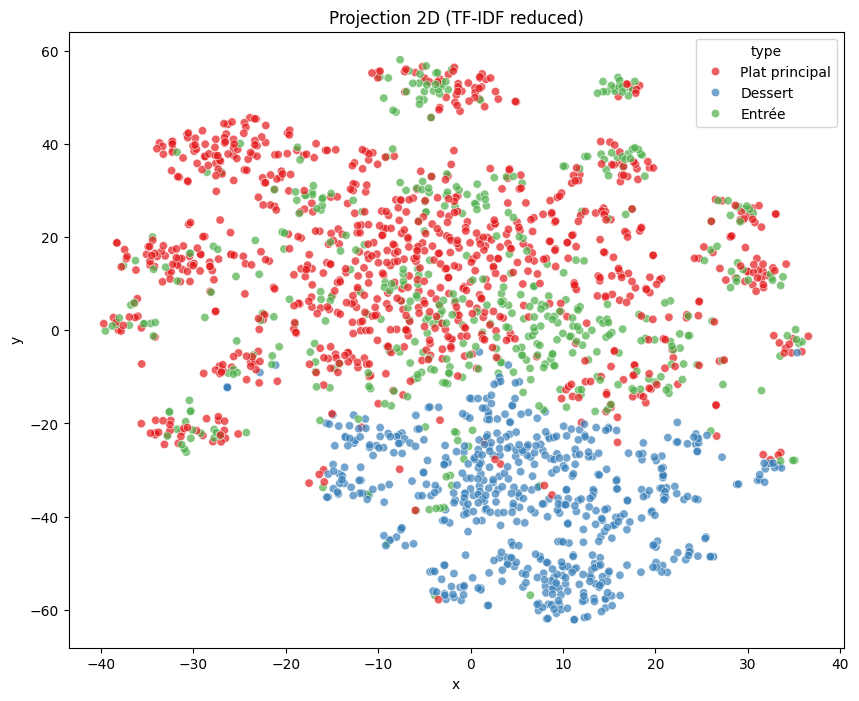

In [73]:
# 1. Echantillon pour faire le TF-IDF sur un échantillon pour ne que ce soit rapide
sample = train.sample(2000, random_state=42)
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(sample['texte'])
svd = TruncatedSVD(n_components=50, random_state=42)
X_svd = svd.fit_transform(X_tfidf)
tsne = TSNE(n_components=2, random_state=42,init="random")
X_2d = tsne.fit_transform(X_svd)

sample['x'] = X_2d[:, 0]
sample['y'] = X_2d[:, 1]

plt.figure(figsize=(10, 8))
sns.scatterplot(data=sample, x='x', y='y', hue='type', palette='Set1', alpha=0.7)
plt.title('Projection 2D (TF-IDF reduced)')
plt.show()

Pour cet méthode, nous avons privilégié la Régression Logistique au lieu du SVM. Comme le démontre notre projection 2D de l'espace TF-IDF (réalisée via une réduction TruncatedSVD suivie d'un t-SNE), si la classe des desserts se différencie nettement, les observations des classes "Entrée" et "Plat principal" forment un amas fortement imbriqué. Géométriquement, il est donc pratiquement impossible de tracer un hyperplan stricte pour séparer ces deux catégories, ce qui pénalise fortement l'approche du SVM. La Régression Logistique s'avère donc beaucoup plus adaptée face à l'ambiguité de la tache car son approche probabiliste permet de modéliser cette incertitude, plutôt que de forcer une séparation stricte.

Nous avons également ajouté le paramètre class_weight='balanced' pour compenser le fort déséquilibre entre nos classes. Puisqu'il y a beaucoup plus de plats que d'entrées, ce réglage force le modèle à donner plus de poids à la catégorie minoritaire, l'empêchant de toujours parier sur les plats par facilité pour limiter l'erreur globale.

**TF-IDF avec n-grams (1, 2)**

In [74]:
# Nouveau vectoriseur avec n-grammes (1, 2)
vectorizer_ngram = TfidfVectorizer(tokenizer=spacy_tokenizer,
                                   lowercase=True,
                                   ngram_range=(1, 2),
                                   max_df=0.95,
                                   min_df=5,
                                   token_pattern=None)

X_train_vec_ngram = vectorizer_ngram.fit_transform(X_train)
X_test_vec_ngram = vectorizer_ngram.transform(X_test)

Régression Logistique

In [75]:
# Entraînement
lr_model = LogisticRegression( class_weight='balanced',random_state=42)
lr_model.fit(X_train_vec_ngram, y_train)

# Prédictions
preds_lr = lr_model.predict(X_test_vec_ngram)

# Evaluation
metrics(preds_lr)

Micro-F1: 0.877521613832853 

Macro-F1: 0.8753937677195758 

Classification Report: 

                precision    recall  f1-score   support

       Dessert       0.98      1.00      0.99       407
        Entrée       0.72      0.83      0.77       337
Plat principal       0.91      0.83      0.87       644

      accuracy                           0.88      1388
     macro avg       0.87      0.88      0.88      1388
  weighted avg       0.88      0.88      0.88      1388

Confusion Matrix:
[[533 107   4]
 [ 53 280   4]
 [  1   1 405]]


**Observations** : Le modèle obtient une très bonne Accuracy globale de 87,7 %, et le Macro-F1 de 87,5 % montre que les résultats sont désormais bien équilibrés entre les classes. D'un côté, les desserts restent très bien reconnus (F1-score de 0,99). De l'autre, grâce aux n-grammes et à l'équilibrage des poids (class_weight), le modèle arrive enfin à bien identifier les entrées (le rappel monte à 0,83). En forçant l'algorithme à donner plus d'importance à cette catégorie, il ne choisit plus systématiquement les plats par défaut. Cependant, cela crée la confusion inverse : le modèle a maintenant tendance à voir des entrées partout. Cela augmente fortement le rappel des entrées, mais fait baisser leur précision (0,72), car beaucoup de plats principaux (107) se retrouvent classés par erreur dans cette catégorie.


### Méthode C : Modèle Enrichi avec Features Linguistiques

Pour la Méthode C, nous avons enrichi la matrice TF-IDF avec des variables structurelles : le nombre d'ingrédients, la longueur de la recette (en mots) et le ratio entre ces deux métriques. Ces nouvelles variables ont d'abord subi une transformation logarithmique (np.log1p) afin de réduire l'asymétrie de leur distribution.  Ensuite, un StandardScaler(with_mean=False) a été appliqué pour mettre ces valeurs à la même échelle que les données TF-IDF, tout en conservant un format de matrice creuse (sparse) pour réaliser la concaténation (hstack). Enfin, la régularisation de la Régression Logistique a été renforcée (C=0.5). Ce réglage permet d'empêcher les milliers de variables textuelles d'écraser l'importance de nos trois nouvelles variables numériques lors de l'apprentissage du modèle.

In [76]:
# nb d'ingrédients
train['nb_ingredients'] = train['ingredients'].fillna('').apply(lambda s: 0 if s.strip()=='' else len([x for x in s.split(',') if x.strip()!='']))
test['nb_ingredients']  = test['ingredients'].fillna('').apply(lambda s: 0 if s.strip()=='' else len([x for x in s.split(',') if x.strip()!='']))

# longueur de la recette en mots
train['len_recette_words'] = train['recette'].fillna('').apply(lambda s: 0 if s.strip()=='' else len(s.split()))
test['len_recette_words']  = test['recette'].fillna('').apply(lambda s: 0 if s.strip()=='' else len(s.split()))

train['ratio_ing'] = train['nb_ingredients'] / (train['len_recette_words'] + 1)
test['ratio_ing'] = test['nb_ingredients'] / (test['len_recette_words'] + 1)

train['len_log'] = np.log1p(train['len_recette_words'])
test['len_log'] = np.log1p(test['len_recette_words'])

train['ing_log'] = np.log1p(train['nb_ingredients'])
test['ing_log'] = np.log1p(test['nb_ingredients'])

num_cols = ['len_log', 'ing_log', 'ratio_ing']
scaler = StandardScaler(with_mean=False)

X_num_train = scaler.fit_transform(train[num_cols].values)
X_num_test  = scaler.transform(test[num_cols].values)

X_num_train_sparse = csr_matrix(X_num_train)
X_num_test_sparse  = csr_matrix(X_num_test)

X_train = hstack([X_train_vec_ngram, X_num_train_sparse])
X_test  = hstack([X_test_vec_ngram,  X_num_test_sparse])

lr_model_enriched = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    C=0.5
)
lr_model_enriched.fit(X_train, y_train)

# Prédictions
preds_lr_enriched = lr_model_enriched.predict(X_test)

# Evaluation
metrics(preds_lr_enriched)

Micro-F1: 0.8659942363112392 

Macro-F1: 0.8637599738556875 

Classification Report: 

                precision    recall  f1-score   support

       Dessert       0.98      1.00      0.99       407
        Entrée       0.69      0.82      0.75       337
Plat principal       0.90      0.81      0.85       644

      accuracy                           0.87      1388
     macro avg       0.86      0.87      0.86      1388
  weighted avg       0.87      0.87      0.87      1388

Confusion Matrix:
[[522 119   3]
 [ 56 275   6]
 [  0   2 405]]


**Observations**: L'intégration des variables structurelles à la matrice entraîne une légère baisse des performances globales par rapport au modèle précédent. L'Accuracy est à 86,6 % et le Macro-F1 à 86,4 %. L'ajout de la longueur de la recette et du nombre d'ingrédients n'a pas permis de résoudre la frontière floue entre les classes "Entrée" et "Plat principal". Au contraire, la matrice de confusion indique une légère dégradation : la précision de la classe "Entrée" chute à 0,69, le modèle classant désormais 119 plats principaux comme des entrées. Le rappel des entrées reste stable (0,82, soit 275 instances bien classées), tout comme les performances sur la classe "Dessert" qui restent optimales (F1-score de 0,99). Ces résultats montrent que les caractéristiques quantitatives (taille, nombre d'ingrédients) se chevauchent trop entre une entrée élaborée et un petit plat principal pour être véritablement discriminantes, ce qui rend l'approche purement lexicale (n-grammes) légèrement plus robuste.

# **Analyse des résultats**

# Analyse quantitative

## Meilleur résultat : Méthode B : Modèle Linéaire (Logistic Regression) avec N-grammes

### Résultats détaillés

Micro-F1: 0.877521613832853  

Macro-F1: 0.8753937677195758  

#### Classification Report

| Classe          | Precision | Recall | F1-score | Support |
|-----------------|----------:|-------:|---------:|--------:|
| Dessert         | 0.98      | 1.00   | 0.99     | 407     |
| Entrée          | 0.72      | 0.83   | 0.77     | 337     |
| Plat principal  | 0.91      | 0.83   | 0.87     | 644     |
| Metric  |       |    |      |      |
| Accuracy      |    |      | 0.88  | 1388 |
| Macro avg     | 0.87 | 0.88 | 0.88 | 1388 |
| Weighted avg  | 0.88 | 0.88 | 0.88 | 1388 |

#### Confusion Matrix

|                | Pred Plat | Pred Entrée | Pred Dessert |
|----------------|----------:|------------:|-------------:|
| **True Plat**  | 533       | 107         | 4            |
| **True Entrée**| 53        | 280         | 4            |
| **True Dessert**| 1        | 1           | 405          |

**Score global**

Le meilleur modèle atteint une performance globale de 87,7 % (Accuracy et Micro-F1). Le score Macro-F1 de 87,5 %, très proche du score global, confirme que le modèle est robuste et équilibré, ne se contentant pas de prédire la classe majoritaire mais réussissant sur l'ensemble des catégories.

**Score par classe**

Les résultats varient selon les catégories : la classe Dessert est quasiment parfaite avec un F1-score de 0,99. La classe Plat principal obtient un bon score de 0,87. En revanche, la classe Entrée est la plus difficile à prédire avec un F1-score de 0,77, montrant que le modèle a plus de mal à identifier précisément cette catégorie.

**Matrice de confusion**

La matrice confirme la quasi-perfection pour les desserts (seulement 2 erreurs). Le problème majeur se situe entre les entrées et les plats : 107 plats principaux ont été confondus avec des entrées, et 53 entrées ont été classées comme plats. Il y a peu de confusion entre les desserts et le reste (4 pour les deux).

**Impact du déséquilibre**

Le jeu de données contient beaucoup plus de plats principaux que d'entrées. Sans correction, le modèle aurait tendance à tout prédire comme "Plat". L'utilisation du paramètre class_weight='balanced' a permis de compenser ce biais, remontant le rappel des entrées à 0,83 malgré leur plus faible nombre.

# Analyse qualitative

**Exemples de bonnes prédictions**

In [87]:
results = pd.DataFrame({
    'Titre': test['titre'],
    'Réel': y_test,
    'Prédit': preds_lr
})
# 2. Bonnes prédictions
bonnes_preds = results[results['Réel'] == results['Prédit']].groupby('Réel').head(2)
print("--- EXEMPLE DE BONNES PRÉDICTIONS ---")
print(bonnes_preds)

--- EXEMPLE DE BONNES PRÉDICTIONS ---
                                                Titre            Réel  \
0                        Roulé à la confiture de lait         Dessert   
1                              Croissants aux amandes         Dessert   
2   Quinoa Phileas (aux légumes croquants et sauci...  Plat principal   
3                 Magret de canard à la crème de mûre  Plat principal   
4   St-Jacques a la sauce aux huitres et aux asperges          Entrée   
15               Velouté de potimarron aux châtaignes          Entrée   

            Prédit  
0          Dessert  
1          Dessert  
2   Plat principal  
3   Plat principal  
4           Entrée  
15          Entrée  


Les bonnes prédictions montrent que le modèle identifie efficacement les recettes contenant des mots-clés explicites, comme "confiture" pour les desserts ou "velouté" pour les entrées, malgré certains termes ambigues comme "crème de mure" dans un plat principal.

**Exemples d’erreurs typiques**

In [85]:
# Erreurs typiques
erreurs_communes = results[(results['Réel'] == 'Plat principal') & (results['Prédit'] == 'Entrée')].head(3)
print("\n--- ERREURS TYPIQUES (Plat / Entrée) ---")
print(erreurs_communes)



--- ERREURS TYPIQUES (Plat / Entrée) ---
                                           Titre            Réel  Prédit
16                  Spaghetti à la sauce sardine  Plat principal  Entrée
18  Gratin aux fruits de mer, vite fait et bon !  Plat principal  Entrée
37                            Turbot à l'oseille  Plat principal  Entrée


Ces erreurs typiques montrent que le modèle confond les Plats principaux légers (poisson, fruits de mer) avec des Entrées. On remarque également la présence de bruit (vite fait et bon) et des mots assez rares (Turbot à l'oseille) qui rendent la tache plus difficile.

**Recettes ambiguës**

In [83]:
# Recettes ambigues
ambigues = results[(results['Réel'] == 'Entrée') & (results['Prédit'] == 'Plat principal')].head(3)
print("\n--- RECETTES AMBIGUËS (Entrée / Plat) ---")
print(ambigues)


--- RECETTES AMBIGUËS (Entrée / Plat) ---
                              Titre    Réel          Prédit
56   Tarte au thon et tomate facile  Entrée  Plat principal
65  Croquettes de jambon au fromage  Entrée  Plat principal
91    Tarte aux brocolis et au bleu  Entrée  Plat principal


Ces erreurs montrent l'ambiguité de certaines recettes : les tartes, quiches et croquettes peuvent être servies aussi bien en Entrée qu'en Plat principal selon la taille de la portion. Le modèle privilégie ici la catégorie "Plat principal" car ces plats partagent des caractéristiques surement fréquentes dans les plats du jeu d'entraînement.

**Différences entre Entrée et Plat principal**

La distinction entre les entrées et les plats principaux est complexe car ces deux catégories partagent un vocabulaire presque identique composé d'ingrédients salés (sel, huile, oignon) et de techniques de base. La différence repose souvent sur des termes plus subtils comme la structure de la recette : les plats principaux affichent généralement une plus grande longueur textuelle, un nombre d'ingrédients plus élevé et des termes plus spécifiques aux plats. À l'inverse, les entrées possèdent peu de termes uniques, ce qui facilite leur confusion avec la classe majoritaire des plats lors de la prédiction. Cette confusion prouve que le texte seul ne suffit pas à créer une frontière nette entre ces deux classes, contrairement aux desserts dont le vocabulaire sucré est fortement discriminant et parfaitement identifié par le modèle.

# Interprétabilité

**Quels mots sont les plus discriminants ?**

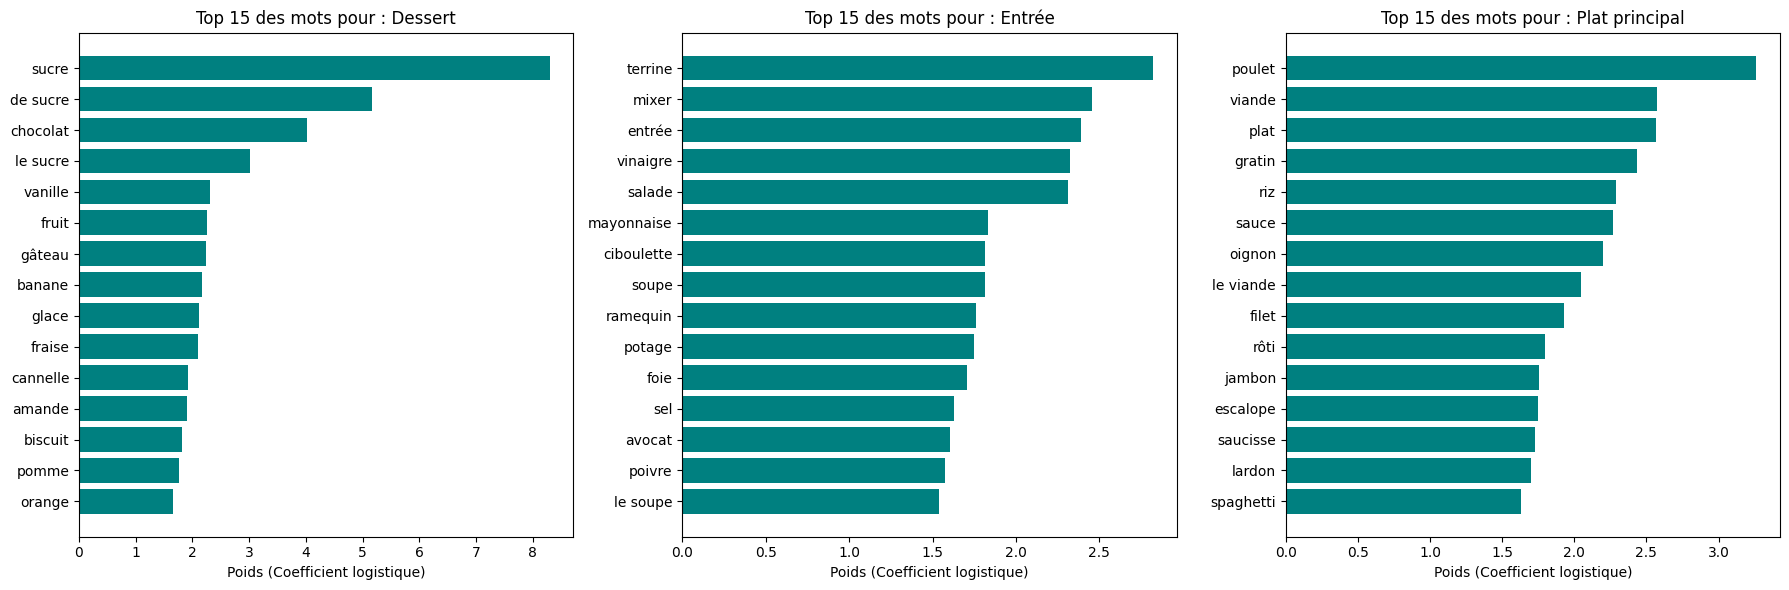

In [77]:
mots = vectorizer_ngram.get_feature_names_out()
coefficients = lr_model.coef_
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

def afficher_top_mots(ax, mots, coefs, nom_classe, top_n=15):
    top_indices = np.argsort(coefs)[-top_n:]
    top_mots = mots[top_indices]
    top_poids = coefs[top_indices]
    ax.barh(top_mots, top_poids, color='teal')
    ax.set_title(f"Top {top_n} des mots pour : {nom_classe}")
    ax.set_xlabel("Poids (Coefficient logistique)")

for i, classe in enumerate(lr_model.classes_):
    afficher_top_mots(axes[i], mots, coefficients[i], classe)

plt.tight_layout()
plt.show()

On observe que la catégorie "Dessert" possède les poids les plus élevés, tandis que la catégorie "Entrée" affiche les plus faibles. Par ailleurs, on remarque que les mots les plus discriminants sont majoritairement des ingrédients. On retrouve également des termes spécifiques aux titres (comme terrine, salade, soupe) ou aux instructions (comme mixer). Cela valide notre choix initial de concaténer les titres, les recettes et les ingrédients.

**Pourquoi votre meilleure méthode fonctionne-t-elle ?**

La meilleure méthode fonctionne car l’utilisation des bi-grammes permet au modèle de prendre en compte les expressions porteuses de sens. Cela change tout pour des expressions comme "pomme de terre" ou "noix de coco", que le TF-IDF de base ne comprenait pas bien. En couplant cela à la régression logistique, qui surpasse le Naive Bayes en calculant des poids précis pour chaque terme au lieu de les traiter comme des probabilités indépendantes, le modèle devient capable de donner un poids précis à ces expressions pour décider de la catégorie. C'est cette combinaison qui a permis de dépasser les scores du TF-IDF simple et d'obtenir les meilleurs résultats du projet.